In [2]:
!curl -L -O https://github.com/mosesyhc/de300-2026sp/raw/refs/heads/main/homework/T_F41SCHEDULE_B43_with_missing.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1577k  100 1577k    0     0  1133k      0  0:00:01  0:00:01 --:--:-- 3051k


In [3]:
import pandas as pd
inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')

/tmp/ipykernel_6729/214319915.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')


In [4]:
inventory.head(10)

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16
5,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7880,N215PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16
6,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7882,N216PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/18/2003 12:00:00 AM,20397.0,16
7,2006,16,PSA Airlines Inc.,2004.0,PSA Airlines Inc.,10135,N702PS,B,Y,70.0,CANADAIR,NaN,RJ-700,67000.0,3/23/2004 12:00:00 AM,20397.0,16
8,2006,16,PSA Airlines Inc.,2004.0,PSA Airlines Inc.,10137,N703PS,B,Y,70.0,CANADAIR,NaN,RJ-700,67000.0,3/26/2004 12:00:00 AM,20397.0,16
9,2006,16,PSA Airlines Inc.,2004.0,PSA Airlines Inc.,10144,N705PS,B,Y,70.0,CANADAIR,NaN,RJ-700,67000.0,4/30/2004 12:00:00 AM,20397.0,16


# ***Task 1***
Investigate the missing data in this dataset. Specifically, for each of the following variables that have missing data, decide if any imputation is possible. Give your reasoning and code for how you decide to impute missing values.

*   Columns for investigation: CARRIER, CARRIER_NAME, MANUFACTURE_YEAR, NUMBER_OF_SEATS, CAPACITY_IN_POUNDS, and AIRLINE_ID.
*   For example, watch out for “North American Airlines” aircrafts. Are the CARRIER/UNIQUE_CARRIER column really missing?
* For CAPACITY_IN_POUNDS and NUMBER_OF_SEATS, identify the category of missingness. Justify your reasoning, and provide a possible imputation method.

In [5]:
cols_to_check = [
    "CARRIER",
    "CARRIER_NAME",
    "MANUFACTURE_YEAR",
    "NUMBER_OF_SEATS",
    "CAPACITY_IN_POUNDS",
    "AIRLINE_ID"
]

missing_summary = pd.DataFrame({
    "missing_count": inventory[cols_to_check].isna().sum(),
    "missing_percent": 100 * inventory[cols_to_check].isna().mean()
})

missing_summary

,missing_count,missing_percent
CARRIER,49,0.037033
CARRIER_NAME,105,0.079357
MANUFACTURE_YEAR,3,0.002267
NUMBER_OF_SEATS,13238,10.005064
CAPACITY_IN_POUNDS,13332,10.076107
AIRLINE_ID,105,0.079357


CARRIER

**Investigation:**  
I examined the rows where CARRIER is missing and compared them with other carrier-identifying columns such as CARRIER_NAME, UNIQUE_CARRIER, and UNIQUE_CARRIER_NAME.

**Reasoning:**  
The rows with missing CARRIER all correspond to North American Airlines. This suggests the value is not truly missing. Instead, the carrier code "NA" was likely interpreted by pandas as a missing value (NaN) when reading the file. Since the airline identity is clearly known from the other columns, this is a data-loading issue rather than genuine missingness.

**Imputation decision:**  
I restored CARRIER = "NA" for rows where CARRIER_NAME is "North American Airlines". This is better described as a correction of misread data than a statistical imputation.

In [6]:
# Filter rows where CARRIER is missing
# When CARRIER is missing, what do the other carrier-related fields look like?
inventory[inventory["CARRIER"].isna()][["CARRIER", "CARRIER_NAME", "UNIQUE_CARRIER", "UNIQUE_CARRIER_NAME"]].drop_duplicates()

,CARRIER,CARRIER_NAME,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME
11776,NaN,North American Airlines,NaN,North American Airlines


In [7]:
def fix_na_carrier(df):
    """
    Restore CARRIER='NA' for North American Airlines rows where
    pandas interpreted 'NA' as a missing value.
    """
    df = df.copy()
    mask = df["CARRIER"].isna() & (df["CARRIER_NAME"] == "North American Airlines")
    df.loc[mask, "CARRIER"] = "NA"
    return df

In [8]:
inventory = fix_na_carrier(inventory)
print("Missing CARRIER after fix:", inventory["CARRIER"].isna().sum())

Missing CARRIER after fix: 0


CARRIER_NAME

**Investigation:**  
I examined the rows where CARRIER_NAME is missing and compared them to other rows with the same CARRIER code.

**Reasoning:**  
For a given carrier code, the carrier name should be consistent within the dataset. By checking non-missing rows with the same CARRIER, I can recover the most likely value for CARRIER_NAME. Because this information is available elsewhere in the dataset, imputation is possible.

**Imputation decision:**  
I imputed missing CARRIER_NAME values using the most common observed CARRIER_NAME among rows with the same CARRIER.

AIRLINE_ID

**Investigation:**  
I inspected the rows with missing AIRLINE_ID and compared them to other rows sharing the same CARRIER code.

**Reasoning:**  
AIRLINE_ID is a carrier identity field, so it should usually be consistent for a given carrier in the dataset. Since the same carrier appears in other rows with non-missing AIRLINE_ID, the missing values can be recovered from those matching rows.

**Imputation decision:**  
I imputed missing AIRLINE_ID values using the most common observed AIRLINE_ID among rows with the same CARRIER.

In [9]:
inventory[inventory["CARRIER_NAME"].isna()][
    ["CARRIER", "CARRIER_NAME", "AIRLINE_ID", "UNIQUE_CARRIER", "UNIQUE_CARRIER_NAME"]
].drop_duplicates().sort_values("CARRIER")

,CARRIER,CARRIER_NAME,AIRLINE_ID,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME
11465,L4,NaN,NaN,NaN,NaN
54610,OH,NaN,NaN,NaN,NaN


In [10]:
import numpy as np

def impute_carrier_name_and_airline_id(df):
    """
    Impute CARRIER_NAME and AIRLINE_ID using the most common value
    among rows with the same CARRIER.
    """
    df = df.copy()

    for col in ["CARRIER_NAME", "AIRLINE_ID"]:
        fill_map = (
            df.dropna(subset=[col])
              .groupby("CARRIER")[col]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )

        missing_mask = df[col].isna()
        df.loc[missing_mask, col] = df.loc[missing_mask, "CARRIER"].map(fill_map)

    return df

In [11]:
inventory = impute_carrier_name_and_airline_id(inventory)

print("Missing CARRIER_NAME after imputation:", inventory["CARRIER_NAME"].isna().sum())
print("Missing AIRLINE_ID after imputation:", inventory["AIRLINE_ID"].isna().sum())

Missing CARRIER_NAME after imputation: 0
Missing AIRLINE_ID after imputation: 0


MANUFACTURE_YEAR

**Investigation:**  
I checked the rows where MANUFACTURE_YEAR is missing and looked at the associated aircraft MODEL.

**Reasoning:**  
Aircraft of the same model tend to come from a similar production period, so the model provides useful information for estimating a missing manufacture year. Because only a small number of rows are missing this value, a simple model-based imputation is reasonable. Using the median within MODEL is more robust than using the mean because it is less affected by unusually old or new aircraft.

**Imputation decision:**  
I imputed missing MANUFACTURE_YEAR values using the median manufacture year within each MODEL, and used the global median only as a fallback if a model-level value was unavailable.

In [12]:
inventory[inventory["MANUFACTURE_YEAR"].isna()][["MANUFACTURER", "MODEL", "MANUFACTURE_YEAR"]]

,MANUFACTURER,MODEL,MANUFACTURE_YEAR
116651,BOEING,B747-400,NaN
124680,BOMBARDIER,CL-600-2C10,NaN
124681,BOMBARDIER,CL-600-2C10,NaN


In [13]:
def impute_manufacture_year(df):
    """
    Impute missing MANUFACTURE_YEAR using the median value within MODEL.
    If needed, fall back to the overall median.
    """
    df = df.copy()

    model_medians = df.groupby("MODEL")["MANUFACTURE_YEAR"].median()
    missing_mask = df["MANUFACTURE_YEAR"].isna()

    df.loc[missing_mask, "MANUFACTURE_YEAR"] = df.loc[missing_mask, "MODEL"].map(model_medians)
    df["MANUFACTURE_YEAR"] = df["MANUFACTURE_YEAR"].fillna(df["MANUFACTURE_YEAR"].median())

    return df

In [14]:
inventory = impute_manufacture_year(inventory)
print("Missing MANUFACTURE_YEAR after imputation:", inventory["MANUFACTURE_YEAR"].isna().sum())

Missing MANUFACTURE_YEAR after imputation: 0


NUMBER_OF_SEATS

**Investigation:**  
I created an indicator for whether NUMBER_OF_SEATS is missing and compared the missingness rate across observed variables such as AIRCRAFT_TYPE and MODEL.

**Reasoning:**  
Missingness is highly concentrated in specific aircraft types and models, with many groups having no missing values and others having all values missing. This indicates that missingness is strongly dependent on aircraft characteristics.

I think it is more consistent with MAR (Missing At Random condition on observed variables) than MCAR. Since seat count is strongly tied to aircraft model, model-level information is useful for imputation.

**Imputation decision:**  
I imputed missing NUMBER_OF_SEATS values using the median number of seats within each MODEL, with the overall median as a fallback.

CAPACITY_IN_POUNDS

**Investigation:**  
I created an indicator for whether CAPACITY_IN_POUNDS is missing and compared the missingness rate across observed variables such as AIRCRAFT_TYPE and MODEL.

**Reasoning:**  
Similar to above, the missingness pattern varies across aircraft types and models, which suggests the data are not MCAR. Instead, the missingness seems related to observed characteristics of the aircraft, making MAR a more appropriate classification. Since capacity is closely related to aircraft model, model-based imputation is more appropriate than using one overall value for the entire dataset.

**Imputation decision:**  
I imputed missing CAPACITY_IN_POUNDS values using the median capacity within each MODEL, with the global median as a fallback.

In [15]:
# create new columns to indicate missingness
# 1 = missing / 0 = not missing
inventory["SEATS_MISSING"] = inventory["NUMBER_OF_SEATS"].isna().astype(int)
inventory["CAPACITY_MISSING"] = inventory["CAPACITY_IN_POUNDS"].isna().astype(int)

print("Missing rate for NUMBER_OF_SEATS:", inventory["SEATS_MISSING"].mean())
print("Missing rate for CAPACITY_IN_POUNDS:", inventory["CAPACITY_MISSING"].mean())

# inventory[inventory["SEATS_MISSING"] == 1].head(10)

Missing rate for NUMBER_OF_SEATS: 0.1000506375034955
Missing rate for CAPACITY_IN_POUNDS: 0.100761074119701


In [16]:
# investigate whether missingness depends on aircraft type
seat_missing_by_type = (
    inventory.groupby("AIRCRAFT_TYPE")["SEATS_MISSING"]
    .mean()
    .sort_values(ascending=False)
)

capacity_missing_by_type = (
    inventory.groupby("AIRCRAFT_TYPE")["CAPACITY_MISSING"]
    .mean()
    .sort_values(ascending=False)
)

print("Seat missingness by AIRCRAFT_TYPE:")
display(seat_missing_by_type.head(150))

print("Capacity missingness by AIRCRAFT_TYPE:")
display(capacity_missing_by_type.head(150))



Seat missingness by AIRCRAFT_TYPE:


,SEATS_MISSING
AIRCRAFT_TYPE,
6871,1.0
6961,1.0
699,1.0
6371,1.0
6231,1.0
...,...
7461,0.0
7481,0.0
2162,0.0


Capacity missingness by AIRCRAFT_TYPE:


,CAPACITY_MISSING
AIRCRAFT_TYPE,
7886,1.0
699,1.0
723,1.0
724,1.0
677,1.0
...,...
6751,0.0
6761,0.0
6711.0,0.0


In [17]:
seat_missing_by_model = (
    inventory.groupby("MODEL")["SEATS_MISSING"]
    .agg(["mean", "count"])
    .sort_values(["mean", "count"], ascending=[False, False])
)

capacity_missing_by_model = (
    inventory.groupby("MODEL")["CAPACITY_MISSING"]
    .agg(["mean", "count"])
    .sort_values(["mean", "count"], ascending=[False, False])
)

print("Seat missingness by MODEL:")
display(seat_missing_by_model.head(15))

print("Capacity missingness by MODEL:")
display(capacity_missing_by_model.head(15))

Seat missingness by MODEL:


,mean,count
MODEL,,
767-332ER-PSGR,1.0,546
B777-222BPAX,1.0,440
B777-2,1.0,380
B767-323ERPASSENGER,1.0,290
B767-322ERPAX,1.0,258
B757-300PAX,1.0,252
B777-200PASSENGER,1.0,236
A330-323-PSGR,1.0,235
767-432ER-PSGR,1.0,231


Capacity missingness by MODEL:


,mean,count
MODEL,,
737-7H4,1.0,569
737-8,1.0,531
ERJ170-200LR,1.0,348
737-823,1.0,277
737-824,1.0,270
737-924ER,1.0,263
737-8H4,1.0,256
CL-600-2D24,1.0,247
208B,1.0,225


In [18]:
def impute_seats_and_capacity(df):
    """
    Impute NUMBER_OF_SEATS and CAPACITY_IN_POUNDS using median values within each MODEL
    """
    df = df.copy()

    for col in ["NUMBER_OF_SEATS", "CAPACITY_IN_POUNDS"]:
        model_medians = df.groupby("MODEL")[col].median()
        missing_mask = df[col].isna()
        df.loc[missing_mask, col] = df.loc[missing_mask, "MODEL"].map(model_medians)
        df[col] = df[col].fillna(df[col].median())

    return df

In [19]:
inventory = impute_seats_and_capacity(inventory)

print("Missing NUMBER_OF_SEATS after imputation:", inventory["NUMBER_OF_SEATS"].isna().sum())
print("Missing CAPACITY_IN_POUNDS after imputation:", inventory["CAPACITY_IN_POUNDS"].isna().sum())

Missing NUMBER_OF_SEATS after imputation: 0
Missing CAPACITY_IN_POUNDS after imputation: 0


In [20]:
inventory = inventory.drop(columns=["SEATS_MISSING", "CAPACITY_MISSING"])

# ***Task 2***
Inspect the columns MANUFACTURER, MODEL, AIRCRAFT_STATUS, and OPERATING_STATUS. Decide, for each column, if transformation or standardization of data are required. Give your reasoning and code if you decide to transform the data.

Hints:
* For very messy data like manufacturer/model names, give your best attempt. It is okay to not catch them all.
* Use value_counts() to identify “big wins”.
* Break down into multiple steps, instead of having one line of code to do them all.

MANUFACTURER

**Is transformation or standardization required?**  
Yes. Standardization is required.

**Reasoning:**  
I inspected the MANUFACTURER column using value_counts() and observed that the same manufacturer appears under multiple variations due to differences in capitalization, punctuation, spacing, and naming conventions (i.e., “BOEING”, “Boeing Co”, “THE BOEING COMPANY”). These variations refer to the same entity but would be treated as distinct values without cleaning, leading to incorrect aggregation and analysis.

**Transformation decision:**  
I standardized the MANUFACTURER column by converting all values to uppercase, removing punctuation and excess whitespace, and mapping common variants to canonical names (i.e., mapping Boeing variants to “BOEING”, Airbus variants to “AIRBUS”). This reduces duplication and ensures consistency across the dataset.

In [21]:
inventory["MANUFACTURER"].value_counts().head(30)
# notice that the same manufacturer appears under multiple names

,count
MANUFACTURER,
BOEING,15922
Embraer,11508
THEBOEINGCO,9223
Bombardier,8871
Boeing,8392
BoeingCo,7446
AIRBUS,7179
AirbusIndustries,6967
BOEINGCOMPANY,6767


In [22]:
def standardize_manufacturer(df):
    """
    Standardize manufacturer names to a consistent format.
    """
    df = df.copy()

    # 1) normalize text
    df["MANUFACTURER"] = (
        df["MANUFACTURER"]
        .astype(str)
        .str.upper()
        .str.strip()
    )

    # 2) remove punctuation and spaces
    df["MANUFACTURER"] = df["MANUFACTURER"].str.replace(r"[\s\.\-,]", "", regex=True)

    # 3) map common variants
    manufacturer_map = {
        "THEBOEINGCO": "BOEING",
        "THEBOEINGCOMPANY": "BOEING",
        "BOEINGCO": "BOEING",
        "AIRBUSINDUSTRIES": "AIRBUS",
        "AIRBUSINDUSTRIE": "AIRBUS",
        "AIRBUSCOMPANY": "AIRBUS",
        "MCDONNELLDOUGLAS": "MCDONNELL-DOUGLAS",
        "MCDONNELDOUGLAS": "MCDONNELL-DOUGLAS",
        "DOUGLASAIRCRAFT": "MCDONNELL-DOUGLAS",
        "CANADAIR": "BOMBARDIER",
        "BOMBARDIERAEROSPACE": "BOMBARDIER",
        "DEHAVILLAND": "DE HAVILLAND",
        "DEHAV": "DE HAVILLAND"
    }

    df["MANUFACTURER"] = df["MANUFACTURER"].replace(manufacturer_map)

    return df

In [23]:
inventory = standardize_manufacturer(inventory)

print("Unique manufacturers after standardization:", inventory["MANUFACTURER"].nunique())
inventory["MANUFACTURER"].value_counts().head(20)

Unique manufacturers after standardization: 121


,count
MANUFACTURER,
BOEING,48750
AIRBUS,23513
BOMBARDIER,16344
EMBRAER,15554
MCDONNELL-DOUGLAS,9506
BOEINGCOMPANY,6767
CESSNA,4514
ATR,1181
DOUGLAS,1137


MODEL

**Is transformation or standardization required?**  
Yes. Moderate standardization is required.

**Reasoning:**  
I inspected the MODEL column using value_counts() and observed substantial inconsistency. The same aircraft models appeared under multiple formats due to differences in capitalization, spacing, punctuation, and prefix usage (i.e., “B-737” vs “B737”, “CRJ200” vs “CRJ-200”). In addition, many entries contained non-informative suffixes such as “PASSENGER”, “PAX”, and “PSGR”, which seem to describe usage rather than the model itself and create unnecessary duplication.

I also observed cases where the manufacturer name was concatenated with the model (i.e., “AIRBUSA320-232”), which led to artificial distinctions between otherwise identical models.

At the same time, many differences in model names represent meaningful distinctions (i.e., “B737-700” vs “B737-800”), so aggressive merging might risk combining different aircraft types.

**Transformation decision:**  
I applied moderate standardization by:
- converting all values to uppercase and trimming whitespace
- removing common non-informative suffixes (i.e., “PASSENGER”, “PAX”, “PSGR”)
- normalizing common formatting patterns (i.e., standardizing “B-737” to “B737” and “CRJ200” to “CRJ-200”)
- removing cases where manufacturer names (i.e., “AIRBUS”) were concatenated with the model.

I avoided merging core model identifiers to preserve meaningful distinctions between aircraft types.

In [24]:
inventory["MODEL"].value_counts().head(50)

,count
MODEL,
EMB-145,2614
B-737-7H4,2470
B737-823,2370
A320-232,2333
A321-231,2259
737-700PASSENGERONLY,2027
C-208B,1872
B757-2,1775
CRJ-2/4,1761


In [25]:
def standardize_model(df):
    df = df.copy()

    # Step 1: basic cleanup
    df["MODEL"] = (
        df["MODEL"]
        .astype(str)
        .str.upper()
        .str.strip()
    )

    df["MODEL"] = df["MODEL"].str.replace(r"\s+", " ", regex=True)

    # Step 2: remove suffix noise (big wins)
    df["MODEL"] = df["MODEL"].str.replace(
        r"(PASSENGERONLY|PASSENGER|ALLPAX|PAX|PSGR)", "", regex=True
    )

    # Step 3: normalize Boeing/Airbus prefixes
    df["MODEL"] = df["MODEL"].str.replace(r"B-?(\d{3})", r"B\1", regex=True)
    df["MODEL"] = df["MODEL"].str.replace(r"A-?(\d{3})", r"A\1", regex=True)

    # Step 4: normalize CRJ / ERJ formatting
    df["MODEL"] = df["MODEL"].str.replace(r"CRJ(\d{3})", r"CRJ-\1", regex=True)
    df["MODEL"] = df["MODEL"].str.replace(r"ERJ(\d{3})", r"ERJ-\1", regex=True)

    # Step 5: clean trailing hyphens / spaces
    df["MODEL"] = df["MODEL"].str.replace(r"-$", "", regex=True)
    df["MODEL"] = df["MODEL"].str.strip()

    return df

In [26]:
inventory = standardize_model(inventory)

inventory["MODEL"].value_counts().head(50)

,count
MODEL,
B737-823,3326
EMB145,3052
CRJ-200,2790
B737-7H4,2474
A320-232,2463
B757-2,2369
A321-231,2299
737-700,2044
CRJ-900,2011


AIRCRAFT_STATUS

**Is transformation or standardization required?**  
Yes. Standardization is required.

**Reasoning:**  
I inspected the AIRCRAFT_STATUS column using value_counts() and found that it consists of single-letter categorical codes (i.e., “O”, “A”, “B”, “L”). However, the same categories appear in both uppercase and lowercase forms (i.e., “B” and “b”, “A” and “a”, “O” and “o”), which would cause them to be treated as different categories.

**Transformation decision:**  
I standardized the column by converting all values to uppercase and removing any extra whitespace. This ensures that each category is represented consistently.

In [27]:
inventory["AIRCRAFT_STATUS"].value_counts(dropna=False)

,count
AIRCRAFT_STATUS,
O,79487
b,30852
B,12699
a,7804
A,1330
L,122
o,19


In [28]:
def standardize_aircraft_status(df):
    """
    Standardize AIRCRAFT_STATUS:
    - uppercase
    - strip whitespace
    """
    df = df.copy()

    df["AIRCRAFT_STATUS"] = (
        df["AIRCRAFT_STATUS"]
        .astype(str)
        .str.upper()
        .str.strip()
    )

    return df

In [29]:
inventory["AIRCRAFT_STATUS"].value_counts(dropna=False)

inventory = standardize_aircraft_status(inventory)

inventory["AIRCRAFT_STATUS"].value_counts(dropna=False)

,count
AIRCRAFT_STATUS,
O,79506
B,43551
A,9134
L,122


OPERATING_STATUS

**Is transformation or standardization required?**  
Yes. Standardization is required.

**Reasoning:**  
I inspected the OPERATING_STATUS column using value_counts() and found that it contains categorical values (“Y” and “N”), along with a small number of lowercase entries (“y”), indicating inconsistent formatting. In addition, there is a small number of missing values in the column.

**Transformation decision:**  
I standardized the column by converting all values to uppercase and removing any extra whitespace to ensure consistency. I also filled the missing value using the mode (most frequent value), since the column is binary and overwhelmingly dominated by one category. This results in a consistent and complete representation of the variable.

In [30]:
inventory["OPERATING_STATUS"].value_counts(dropna=False)

,count
OPERATING_STATUS,
Y,126577
N,5664
y,71
,1


In [31]:
def standardize_operating_status(df):
    df = df.copy()

    # Convert to string safely, but preserve NaN
    df["OPERATING_STATUS"] = df["OPERATING_STATUS"].where(
        df["OPERATING_STATUS"].notna(), None
    )

    df["OPERATING_STATUS"] = (
        df["OPERATING_STATUS"]
        .astype(str)
        .str.upper()
        .str.strip()
    )

    # Convert "NONE" or "NAN" strings back to actual NaN
    df["OPERATING_STATUS"] = df["OPERATING_STATUS"].replace(
        ["NONE", "NAN", ""], np.nan
    )

    # Fill missing with mode
    df["OPERATING_STATUS"] = df["OPERATING_STATUS"].fillna(
        df["OPERATING_STATUS"].mode()[0]
    )

    return df

In [32]:
inventory = standardize_operating_status(inventory)

inventory["OPERATING_STATUS"].value_counts(dropna=False)

,count
OPERATING_STATUS,
Y,126649
N,5664


Task 3

Remove data rows that still have missing values. Report the amount of remaining data you obtained.


---


After removing all rows with remaining missing values, the dataset contains 101287 rows. In total, 31026 rows were removed during this step.

In [33]:
# Check remaining missing values
inventory.isna().sum()

,0
YEAR,0
CARRIER,0
CARRIER_NAME,0
MANUFACTURE_YEAR,0
UNIQUE_CARRIER_NAME,105
SERIAL_NUMBER,0
TAIL_NUMBER,0
AIRCRAFT_STATUS,0
OPERATING_STATUS,0
NUMBER_OF_SEATS,0


In [34]:
# Count rows before dropping
rows_before = len(inventory)
print("Rows before dropping:", rows_before)

Rows before dropping: 132313


In [35]:
# Drop rows with missing values
inventory = inventory.dropna()

In [36]:
# Count rows after
rows_after = len(inventory)
print("Rows after dropping:", rows_after)

print("Rows removed:", rows_before - rows_after)

Rows after dropping: 101287
Rows removed: 31026


In [37]:
# to verify that theyre all 0's now
inventory.isna().sum()

,0
YEAR,0
CARRIER,0
CARRIER_NAME,0
MANUFACTURE_YEAR,0
UNIQUE_CARRIER_NAME,0
SERIAL_NUMBER,0
TAIL_NUMBER,0
AIRCRAFT_STATUS,0
OPERATING_STATUS,0
NUMBER_OF_SEATS,0


Task 4

Transformation and derivative variables

* For the columns NUMBER_OF_SEATS and CAPACITY_IN_POUNDS, check the skewness in the variable and plot a histogram for each variable.
* The Box-Cox transformation (scipy.stats.boxcox) is one possible way to transform variables into a “more-normal-like” variable.
* Apply the Box-Cox transformation for these two columns and save them as new columns, i.e. XXXXXXXXX_BOXCOX.
* Plot a histogram for each transformed variable.
* Describe what you observe before and after transformation.


---

The skewness of NUMBER_OF_SEATS is -0.27, indicating a roughly symmetric distribution with a slight left skew. This suggests that the data are fairly balanced, with a mild tendency toward higher seat counts rather than a long right tail.

The skewness of CAPACITY_IN_POUNDS is 4.31, indicating a highly right-skewed distribution. This suggests that while most aircraft have relatively low to moderate capacity, a small number of aircraft have extremely large capacities, creating a long right tail.


---


Before transformation, the distribution of NUMBER_OF_SEATS shows a large spike at 0 and a spread of values across typical seat counts, with no strong overall skew but noticeable clustering. After applying the Box-Cox transformation, the distribution remains largely similar in shape, with only minor compression of the scale. The transformation does not significantly improve normality, primarily because the data is not heavily skewed and the large concentration of zero values continues to dominate the distribution.

Before transformation, the distribution of CAPACITY_IN_POUNDS is highly right-skewed, with most observations concentrated at lower values and a long tail extending toward very large capacities. After applying the Box-Cox transformation, the distribution becomes more symmetric and takes on a more bell-shaped form, with the right tail significantly compressed. This indicates that the transformation makes the data more normal-like and reduces the influence of extreme values.

In [38]:
# check skewness
seats_skew = inventory["NUMBER_OF_SEATS"].skew()
print("Skewness of NUMBER_OF_SEATS:", seats_skew)

capacity_skew = inventory["CAPACITY_IN_POUNDS"].skew()
print("Skewness of CAPACITY_IN_POUNDS:", capacity_skew)

Skewness of NUMBER_OF_SEATS: -0.34276824893503777
Skewness of CAPACITY_IN_POUNDS: 4.042393316197075


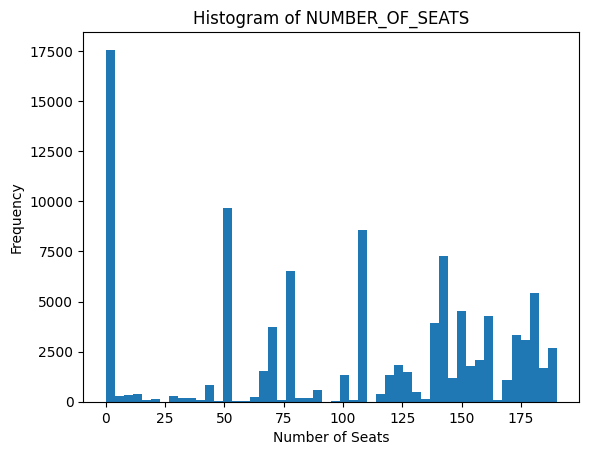

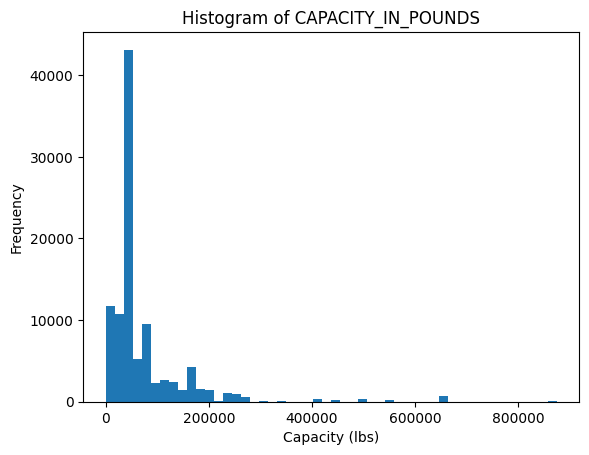

In [39]:
# plot histograms
import matplotlib.pyplot as plt

plt.figure()
plt.hist(inventory["NUMBER_OF_SEATS"], bins=50)
plt.title("Histogram of NUMBER_OF_SEATS")
plt.xlabel("Number of Seats")
plt.ylabel("Frequency")
plt.show()

import matplotlib.pyplot as plt

plt.figure()
plt.hist(inventory["CAPACITY_IN_POUNDS"], bins=50)
plt.title("Histogram of CAPACITY_IN_POUNDS")
plt.xlabel("Capacity (lbs)")
plt.ylabel("Frequency")
plt.show()

In [40]:
# check for 0's
print((inventory["NUMBER_OF_SEATS"] <= 0).sum())
print((inventory["CAPACITY_IN_POUNDS"] <= 0).sum())

17513
1865


In [41]:
def apply_boxcox_transformations(df):
    df = df.copy()
    seats = df["NUMBER_OF_SEATS"]
    capacity = df["CAPACITY_IN_POUNDS"]
    if seats.min() <= 0:
        seats = seats + 1
    if capacity.min() <= 0:
        capacity = capacity + 1
    df["NUMBER_OF_SEATS_BOXCOX"], _ = boxcox(seats)
    df["CAPACITY_IN_POUNDS_BOXCOX"], _ = boxcox(capacity)
    return df

In [42]:
from scipy.stats import boxcox

inventory = apply_boxcox_transformations(inventory)

# print lambdas separately since the function doesn't return them
seats = inventory["NUMBER_OF_SEATS"]
if seats.min() <= 0:
    seats = seats + 1
_, lambda_seats = boxcox(seats)

capacity = inventory["CAPACITY_IN_POUNDS"]
if capacity.min() <= 0:
    capacity = capacity + 1
_, lambda_capacity = boxcox(capacity)

print("Lambda (NUMBER_OF_SEATS):", lambda_seats)
print("Lambda (CAPACITY_IN_POUNDS):", lambda_capacity)

Lambda (NUMBER_OF_SEATS): 0.6650148875819938
Lambda (CAPACITY_IN_POUNDS): 0.29743282300774226


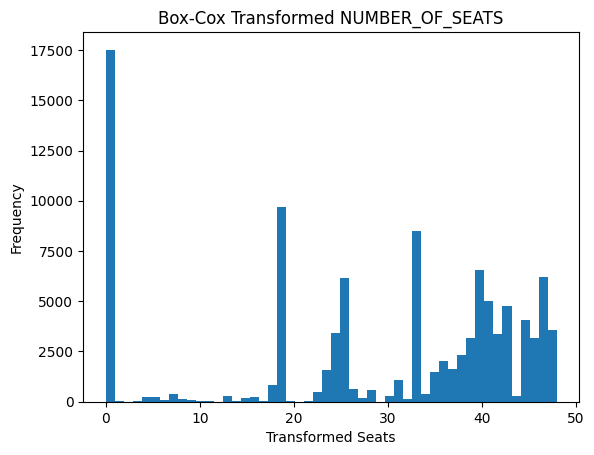

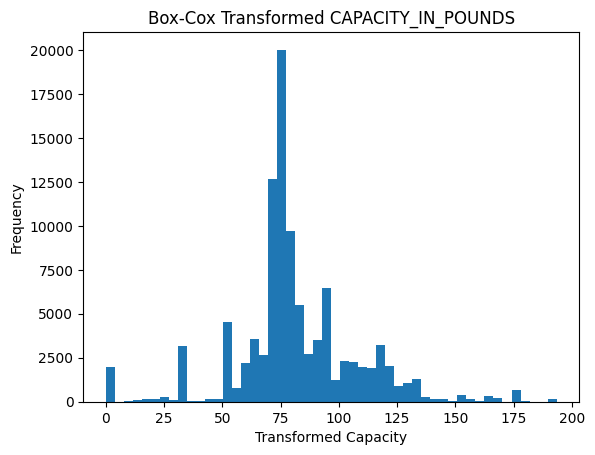

In [43]:
# plot histograms ater transformations
import matplotlib.pyplot as plt

# NUMBER_OF_SEATS (Box-Cox)
plt.figure()
plt.hist(inventory["NUMBER_OF_SEATS_BOXCOX"], bins=50)
plt.title("Box-Cox Transformed NUMBER_OF_SEATS")
plt.xlabel("Transformed Seats")
plt.ylabel("Frequency")
plt.show()

# CAPACITY_IN_POUNDS (Box-Cox)
plt.figure()
plt.hist(inventory["CAPACITY_IN_POUNDS_BOXCOX"], bins=50)
plt.title("Box-Cox Transformed CAPACITY_IN_POUNDS")
plt.xlabel("Transformed Capacity")
plt.ylabel("Frequency")
plt.show()

Task 5

Feature engineering

* Create a new column SIZE by the quartiles of NUMBER_OF_SEATS
  * below 25% percentile: SMALL
  * 25% - 50% percentile: MEDIUM
  * 50% - 75% percentile: LARGE
  * above 75% percentile: XLARGE
* For each size group, provide and plot the proportions of aircrafts that are operating versus not (OPERATING_STATUS).
* For each size group, provide and plot the proportions of aircrafts belonging to each aircraft status group (AIRCRAFT_STATUS).
* Provide a written summary of your findings.



---

Across all aircraft size groups, the vast majority of aircraft are operating, with over 94% operating in every category. There is a slight upward trend, where larger aircraft are more likely to be operating, increasing from about 94% for small aircraft to nearly 97% for extra-large aircraft.

Looking at aircraft status, “O” is the most common category across all size groups and becomes more dominant as aircraft size increases. The proportion of “B” decreases steadily as size increases, indicating that smaller aircraft are more likely to fall into this category. The proportion of “A” increases from small to large aircraft but slightly decreases for extra-large aircraft, while “L” remains negligible across all groups.

Overall, larger aircraft tend to be more consistently operational and are more concentrated in the primary “O” status category, while smaller aircraft exhibit slightly more variation in status.

In [44]:
def create_size_column(df):
    df = df.copy()
    q1 = df["NUMBER_OF_SEATS"].quantile(0.25)
    q2 = df["NUMBER_OF_SEATS"].quantile(0.50)
    q3 = df["NUMBER_OF_SEATS"].quantile(0.75)
    df["SIZE"] = pd.cut(
        df["NUMBER_OF_SEATS"],
        bins=[-float("inf"), q1, q2, q3, float("inf")],
        labels=["SMALL", "MEDIUM", "LARGE", "XLARGE"]
    )
    return df

inventory = create_size_column(inventory)

In [45]:
# create proportions table and print
status_prop = (
    inventory.groupby("SIZE")["OPERATING_STATUS"]
    .value_counts(normalize=True)
    .unstack()
)

print("Proportion of OPERATING_STATUS within each SIZE group:")
display(status_prop)

Proportion of OPERATING_STATUS within each SIZE group:


/tmp/ipykernel_6729/4282451855.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inventory.groupby("SIZE")["OPERATING_STATUS"]


OPERATING_STATUS,N,Y
SIZE,,
SMALL,0.048170,0.951830
MEDIUM,0.036717,0.963283
LARGE,0.037526,0.962474
XLARGE,0.027129,0.972871


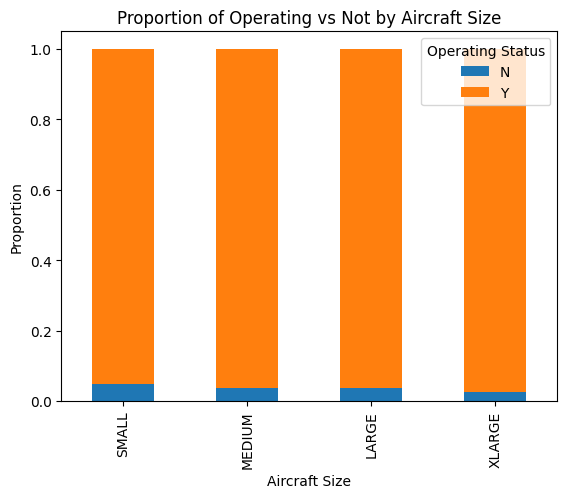

In [46]:
# plot propertions
import matplotlib.pyplot as plt

status_prop.plot(kind="bar", stacked=True)
plt.title("Proportion of Operating vs Not by Aircraft Size")
plt.xlabel("Aircraft Size")
plt.ylabel("Proportion")
plt.legend(title="Operating Status")
plt.show()

In [47]:
# create proportions table and print
aircraft_status_prop = (
    inventory.groupby("SIZE")["AIRCRAFT_STATUS"]
    .value_counts(normalize=True)
    .unstack()
)

print("Proportion of AIRCRAFT_STATUS within each SIZE group:")
display(aircraft_status_prop)

Proportion of AIRCRAFT_STATUS within each SIZE group:


/tmp/ipykernel_6729/43034588.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inventory.groupby("SIZE")["AIRCRAFT_STATUS"]


AIRCRAFT_STATUS,A,B,L,O
SIZE,,,,
SMALL,0.039997,0.390472,0.000000,0.569530
MEDIUM,0.057106,0.339654,0.000562,0.602678
LARGE,0.145234,0.213434,0.003220,0.638113
XLARGE,0.066899,0.240047,0.001302,0.691752


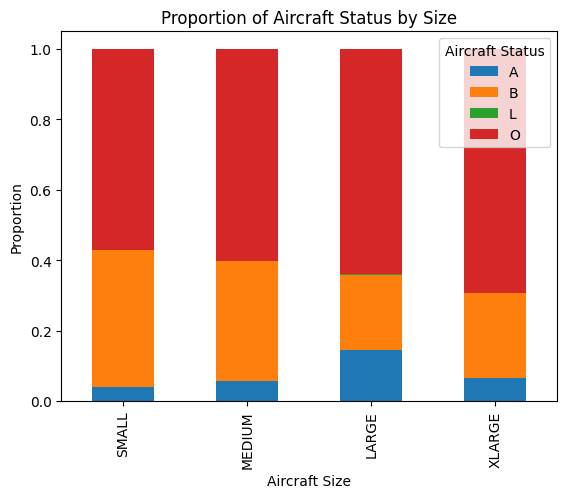

In [48]:
# plot proportions
import matplotlib.pyplot as plt

aircraft_status_prop.plot(kind="bar", stacked=True)
plt.title("Proportion of Aircraft Status by Size")
plt.xlabel("Aircraft Size")
plt.ylabel("Proportion")
plt.legend(title="Aircraft Status")
plt.show()

Task 6:

Modeling refresher

* Randomly split your data into 80% training and 20% testing data.
* Create four models in total:
  * Predict NUMBER_OF_SEATS with a multivariate regression model.
  * Predict CAPACITY_IN_POUNDS with a multivariate regression model.
  * Predict NUMBER_OF_SEATS with a random forest model.
  * Predict CAPACITY_IN_POUNDS with a random forest model.
* Report the training and testing error (RMSE). Comment on your observation about their performances.



---

Random forest substantially outperforms linear regression for both targets. For NUMBER_OF_SEATS, linear regression has a test RMSE of 59.11, while random forest brings it down to 2.22, a dramatic improvement. For CAPACITY_IN_POUNDS, linear regression has a test RMSE of 89674 lbs vs 32429 lbs for random forest.

Both linear regression models show nearly identical train and test RMSE (~59 and ~88867 respectively), which indicates the model is too simple to capture the structure in the data (high bias, low variance).

The random forest shows a small gap between train and test RMSE for both targets (2.06 vs 2.22 for seats; 29263 vs 32429 for capacity), suggesting mild overfitting but strong generalization overall.

CAPACITY_IN_POUNDS remains harder to predict than NUMBER_OF_SEATS for both models, likely because aircraft capacity varies more continuously and is influenced by configuration factors not fully captured by the available features.

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import numpy as np

def build_models(df):
    """
    Train and evaluate multivariate regression and random forest models
    for NUMBER_OF_SEATS and CAPACITY_IN_POUNDS. Returns a DataFrame of RMSE results.
    """
    df = df.copy()

    # encode categorical columns
    for col in ["MANUFACTURER", "MODEL", "AIRCRAFT_STATUS", "OPERATING_STATUS", "SIZE"]:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    features = ["MANUFACTURE_YEAR", "MANUFACTURER", "MODEL",
                "AIRCRAFT_STATUS", "OPERATING_STATUS", "SIZE"]

    results = {}

    for target in ["NUMBER_OF_SEATS", "CAPACITY_IN_POUNDS"]:
        X = df[features]
        y = df[target]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Linear Regression
        lr = LinearRegression()
        lr.fit(X_train, y_train)
        results[f"LinearRegression_{target}"] = {
            "train_RMSE": np.sqrt(mean_squared_error(y_train, lr.predict(X_train))),
            "test_RMSE":  np.sqrt(mean_squared_error(y_test,  lr.predict(X_test)))
        }

        # Random Forest
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        results[f"RandomForest_{target}"] = {
            "train_RMSE": np.sqrt(mean_squared_error(y_train, rf.predict(X_train))),
            "test_RMSE":  np.sqrt(mean_squared_error(y_test,  rf.predict(X_test)))
        }

    return pd.DataFrame(results).T.round(2)

In [50]:
results_df = build_models(inventory)
display(results_df)

,train_RMSE,test_RMSE
LinearRegression_NUMBER_OF_SEATS,59.45,59.11
RandomForest_NUMBER_OF_SEATS,2.06,2.22
LinearRegression_CAPACITY_IN_POUNDS,88866.54,89674.48
RandomForest_CAPACITY_IN_POUNDS,29263.20,32428.60
